## FRED-MD 데이터셋을 이용하여, 소비자물가지수 상승률(전년동월대비) 예측

#### 라이브러리와 모듈 불러오기

In [ ]:
import pandas as pd
import ml

#### 데이터 불러오기(FRED-MD meta, data)

In [3]:
meta = pd.read_csv('FRED-MD_updated_appendix.csv', encoding='cp1252', index_col = 0)

In [4]:
df_raw = pd.read_csv('2025-06-MD.csv', index_col=0, skiprows=[1])

In [5]:
df_raw.index = pd.DatetimeIndex(df_raw.index, freq='MS')

In [6]:
meta[meta['description'].str.contains('CPI')]

,tcode,fred,description,gsi,gsi:description,group
id,,,,,,
113,6,CPIAUCSL,CPI : All Items,M_110157323,CPI-U: all,7
114,6,CPIAPPSL,CPI : Apparel,M_110157299,CPI-U: apparel,7
115,6,CPITRNSL,CPI : Transportation,M_110157302,CPI-U: transp,7
116,6,CPIMEDSL,CPI : Medical Care,M_110157304,CPI-U: medical,7
117,6,CUSR0000SAC,CPI : Commodities,M_110157314,CPI-U: comm.,7
118,6,CUSR0000SAD,CPI : Durables,M_110157315,CPI-U: dbles,7
119,6,CUSR0000SAS,CPI : Services,M_110157325,CPI-U: services,7
120,6,CPIULFSL,CPI : All Items Less Food,M_110157328,CPI-U: ex food,7
121,6,CUSR0000SA0L2,CPI : All items less shelter,M_110157329,CPI-U: ex shelter,7


In [7]:
transformer = ml.FredMdTransformer(meta, id_col='fred', tcode_col='tcode')

In [8]:
df = transformer.transform(df_raw)

In [9]:
df = df.ffill() # fillna(method='ffill')
df = df.dropna(axis = 0)

In [10]:
df

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1992-03-01,0.001467,0.000590,0.001830,0.004017,-0.003411,0.008381,0.008338,0.008783,0.008871,0.020222,...,0.001291,-0.000182,0.000836,0.011670,-0.003556,7.2,-0.016313,0.001663,-0.003791,16.2227
1992-04-01,0.003587,0.002574,0.000833,0.006642,0.007998,0.007652,0.007433,0.007499,0.009322,0.018415,...,-0.002156,0.000792,0.000830,-0.005836,0.001759,1.2,0.037147,-0.005843,0.001367,16.1885
1992-05-01,0.005188,0.005346,0.005164,-0.008738,0.003433,0.003283,0.005520,0.005877,0.006537,0.030857,...,0.000964,-0.002580,-0.002514,-0.000726,-0.000890,2.0,-0.052941,0.000207,0.004045,14.7280
1992-06-01,0.004069,0.004316,0.002703,0.010487,0.004564,0.000564,-0.002470,-0.003155,-0.004910,-0.013889,...,0.003219,0.000265,0.002500,0.007957,-0.000883,1.2,0.045621,0.008812,-0.000894,14.7531
1992-07-01,-0.000888,-0.001450,0.003318,0.013303,0.010183,0.009022,0.010146,0.011477,0.013214,0.026242,...,-0.002373,0.002632,-0.004169,-0.015187,-0.000003,-3.8,-0.003523,-0.008544,0.002273,13.3036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,0.001627,-0.000262,-0.005630,-0.009748,-0.008678,-0.001072,0.002419,0.002470,-0.000426,-0.021047,...,0.001610,-0.000605,0.001865,-0.001115,0.004895,-2.3,-0.005388,-0.003604,0.000176,16.8122
2025-02-01,0.002893,-0.000103,-0.000997,0.006954,0.000416,0.010303,0.011455,0.013269,0.011196,0.040908,...,-0.004609,0.001931,-0.003781,-0.000831,-0.006689,-7.0,-0.005596,-0.004941,0.006591,17.0705
2025-03-01,0.006241,0.005705,0.006774,0.013401,0.015081,-0.002426,-0.001518,-0.002450,-0.009213,0.004013,...,-0.008475,-0.002719,0.004354,0.001080,0.006248,-7.7,0.001423,0.001327,0.004257,21.6579


### Random Forest 학습 및 예측

In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pandas.tseries.offsets import MonthBegin
import numpy as np

In [12]:
tscv = TimeSeriesSplit(n_splits = 3, test_size = 1)

In [59]:
X = df.drop(columns=['CPIAUCSL']) # features
y = df['CPIAUCSL'] # target

#### 예측시계에 맞춰 X, y 조정

In [60]:
hor = 1 # 1개월 뒤 예측
y_shifted = y.shift(-hor) # 예측시점 조정, y.shift(-h) = y_t+h, y.shift(t) = y_t-h

In [61]:
pd.concat([y, y.shift(-hor), X], axis=1).iloc[:,:3].tail()

,CPIAUCSL,CPIAUCSL,RPI
sasdate,,,
2025-01-01,2.999413,2.814270,0.001627
2025-02-01,2.814270,2.405585,0.002893
2025-03-01,2.405585,2.333747,0.006241
2025-04-01,2.333747,2.375934,0.006146
2025-05-01,2.375934,NaN,-0.005613


In [62]:
X2 = X.copy()
y2 = y_shifted.copy()

Xy = pd.concat([X2, y2], axis=1).dropna()
X2 = Xy.drop(columns = 'CPIAUCSL')
y2 = Xy['CPIAUCSL']

In [63]:
actual = []
pred = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X2), 1):
    print(f"Fold {fold}")
    tm = (y2.index[test_idx] + MonthBegin(hor)).strftime('%Y-%m') # target month
    print(f"Predictor timestamp: {X2.index[test_idx].strftime('%Y-%m')[0]}, Target month: {tm[0]}") # 예측시계별 Xy 조정으로 실제 예측시점은 1개월 뒤 

    X_train, X_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=1000, max_depth=3, max_features=0.5, random_state=42) # random_state=42
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    actual.append(np.array(y_test))
    pred.append(y_pred)

print("평균 MAE:", np.round(mean_absolute_error(actual, pred), 4))
print("평균 RMSE:", np.round(np.sqrt(mean_squared_error(actual, pred)), 4))

Fold 1
Predictor timestamp: 2025-02, Target month: 2025-03
Fold 2
Predictor timestamp: 2025-03, Target month: 2025-04
Fold 3
Predictor timestamp: 2025-04, Target month: 2025-05
평균 MAE: 0.2137
평균 RMSE: 0.2171


#### 특성 중요도(feature importance)

In [64]:
top_imp = pd.DataFrame({'RF': model.feature_importances_}, index=X2.columns).nlargest(10, 'RF')
top_imp.sort_values('RF', ascending=False).head(10) # ascending=False → 내림차순

,RF
BUSINVx,0.193101
TB3SMFFM,0.189626
CES1021000001,0.139832
TB6SMFFM,0.090263
HWIURATIO,0.061086
PERMITS,0.033312
CES0600000007,0.029414
AWHMAN,0.026651
M2REAL,0.021434
PERMITMW,0.019880


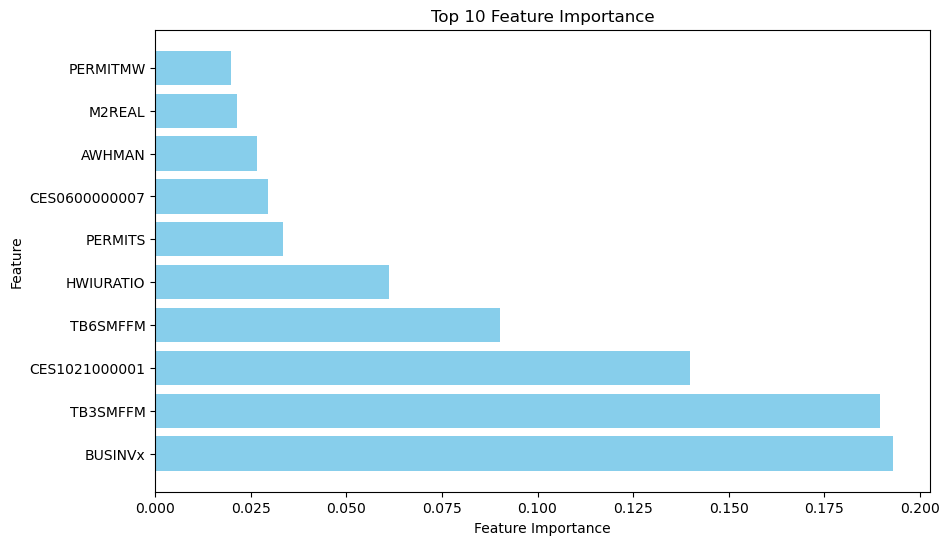

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_imp.index, top_imp['RF'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance')
plt.show()

#### Decision tree와 비교

In [18]:
from sklearn.tree import DecisionTreeRegressor

In [19]:
actual = []
pred = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X2), 1):
    print(f"Fold {fold}")
    tm = (y2.index[test_idx] + MonthBegin(hor)).strftime('%Y-%m') # target month
    print(f"Predictor timestamp: {X2.index[test_idx].strftime('%Y-%m')[0]}, Target month: {tm[0]}") # 예측시계별 Xy 조정으로 실제 예측시점은 1개월 뒤 

    X_train, X_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]
    
    model = DecisionTreeRegressor(max_depth=7, max_features=0.5, random_state=42) # random_state=42
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    actual.append(np.array(y_test))
    pred.append(y_pred)

print("평균 MAE:", np.round(mean_absolute_error(actual, pred), 4))
print("평균 RMSE:", np.round(np.sqrt(mean_squared_error(actual, pred)), 4))

Fold 1
Predictor timestamp: 2025-02, Target month: 2025-03
Fold 2
Predictor timestamp: 2025-03, Target month: 2025-04
Fold 3
Predictor timestamp: 2025-04, Target month: 2025-05
평균 MAE: 0.5832
평균 RMSE: 0.5839


### 하이퍼 파라미터 튜닝

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

#### Grid Search

In [21]:
# 파라미터 그리드 정의
param_grid = {
    'n_estimators': [1000],
    'max_depth': [3, 5, 7, 10],
    'max_features': [0.3, 0.5, 0.7, 1.0]
}

# MAE를 최소화하는 방향으로 튜닝
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

model = RandomForestRegressor(random_state=42)

# grid_search 인스턴스 생성
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=mae_scorer,
    cv=tscv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X2, y2)

print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최적 MAE:", round(-grid_search.best_score_, 4)) # -붙이는 이유는 최소화하는 방향으로 튜닝하기 때문

Fitting 3 folds for each of 16 candidates, totalling 48 fits
최적 하이퍼파라미터: {'max_depth': 3, 'max_features': 0.3, 'n_estimators': 1000}
최적 MAE: 0.202


#### Randomized Search

In [218]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [219]:
# MAE를 최소화하는 방향으로 튜닝
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# RandomForest 기본 모델
model = RandomForestRegressor(random_state=42)

# 1) RandomizedSearchCV용 파라미터 분포 정의
param_dist = {
    'n_estimators': randint(500, 1000),     # 500 ~ 1000 사이 정수
    'max_depth':    randint(2, 12),         # 2 ~ 12 사이 정수
    'max_features': uniform(0.3, 0.8),      # 0.3 ~ 0.8 사이 연속
}

# 2) RandomizedSearchCV 인스턴스 생성
rand_search = RandomizedSearchCV(
    estimator     = model,
    param_distributions = param_dist,
    n_iter        = 50,              # 무작위 조합 50번 탐색
    scoring       = mae_scorer,
    cv            = tscv,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = 2
)

# 3) 학습 및 결과 확인
rand_search.fit(X2, y2)
print("최적 하이퍼파라미터 (Randomized):", rand_search.best_params_)
print("최적 MAE (Randomized):", round(-rand_search.best_score_, 4))

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
18 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    

최적 하이퍼파라미터 (Randomized): {'max_depth': 2, 'max_features': np.float64(0.3125091253929551), 'n_estimators': 508}
최적 MAE (Randomized): 0.1645


### 모형 추가하기

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [25]:
# 모델 정의
models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=1000, max_depth=3, max_features=0.5, random_state=42
    ),
    'LinearRegression': Pipeline([
        ('select', ml.RandomFeatureSelector(k=3, random_state=42)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scale', StandardScaler()),
        ('lasso', Lasso(alpha=0.1, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('scale', StandardScaler()),
        ('enet', ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)) #l1_ratio=1 → Lasso, l1_ratio=0 → Ridge
    ]),
    'GBM': GradientBoostingRegressor(
        n_estimators=1000, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
    ),
    'XGB': XGBRegressor(
        n_estimators=1000, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
    ),
}

In [26]:
results = {
    name: {'actual': [], 'pred': []} 
    for name in models
} # 결과 저장용 딕셔너리

In [27]:
# 예측시계
hor = 1

# Walk-forward
for fold, (train_idx, test_idx) in enumerate(tscv.split(X2), 1):
    print(f"Fold {fold}")
    tm = (y2.index[test_idx] + MonthBegin(hor)).strftime('%Y-%m')
    print(f"Predictor timestamp: {X2.index[test_idx].strftime('%Y-%m')[0]}, Target month: {tm[0]}")

    X_train, X_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]

    for name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)
        print(f"Model: {name} is fitted")
        # 예측
        y_pred = model.predict(X_test)
        # 결과 저장
        idx = y2.index[test_idx] + MonthBegin(hor)
        results[name]['actual'].append(pd.Series(y_test.values, index=idx))
        results[name]['pred'].append(pd.Series(y_pred, index=idx))

# 결과
for name in models:
    actual = pd.concat(results[name]['actual']).sort_index()
    pred   = pd.concat(results[name]['pred']).sort_index()
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name:20s} → MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Fold 1
Predictor timestamp: 2025-02, Target month: 2025-03
Model: RandomForest
Model: LinearRegression
Model: Ridge
Model: Lasso
Model: ElasticNet
Model: GBM
Model: XGB
Fold 2
Predictor timestamp: 2025-03, Target month: 2025-04
Model: RandomForest
Model: LinearRegression
Model: Ridge
Model: Lasso
Model: ElasticNet
Model: GBM
Model: XGB
Fold 3
Predictor timestamp: 2025-04, Target month: 2025-05
Model: RandomForest
Model: LinearRegression
Model: Ridge
Model: Lasso
Model: ElasticNet
Model: GBM
Model: XGB
RandomForest         → MAE: 0.2137, RMSE: 0.2171
LinearRegression     → MAE: 0.2088, RMSE: 0.2819
Ridge                → MAE: 1.4973, RMSE: 1.5055
Lasso                → MAE: 0.3958, RMSE: 0.4622
ElasticNet           → MAE: 0.4487, RMSE: 0.4843
GBM                  → MAE: 0.2772, RMSE: 0.3311
XGB                  → MAE: 0.3253, RMSE: 0.3584


### 하이퍼파라미터 튜닝

In [44]:
param_grid = {
    'RandomForest': {
        'n_estimators': [1000],
        'max_depth': [3, 5, 7, 10],
        'max_features': [0.3, 0.5, 0.7, 1.0]
    },
    'LinearRegression': {
        'select__k': [3, 5, 7, 10] # select__k → select.k
    },
    'Ridge': {
        'ridge__alpha': [0.1, 0.5, 1.0]
    },
    'Lasso': {
        'lasso__alpha': [0.1, 0.5, 1.0]
    },
    'ElasticNet': {
        'enet__alpha': [0.1, 0.5, 1.0],
        'enet__l1_ratio': [0.1, 0.5, 1.0]
    },
    'GBM': {
        'n_estimators': [1000],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0]
    },
    'XGB': {
        'n_estimators': [1000],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0]
    },
}

In [82]:
# RMSE를 최소화하는 방향으로 튜닝
scoring='neg_root_mean_squared_error'
# 또는 rmse_scorer = make_scorer(lambda x, y: np.sqrt(mean_squared_error(x, y)), greater_is_better=False)

grid_searches = {} # 모델별 그리드 서치 결과 저장 딕셔너리

for name, model in models.items():
    print(f"GridSearchCV for: {name}")
    param = param_grid[name]
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param,
        scoring=scoring,
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )
    grid_search.fit(X2, y2)
    grid_searches[name] = grid_search
    
    print(f"최적 하이퍼파라미터: {grid_search.best_params_}")
    print(f"최적 RMSE: {round(-grid_search.best_score_, 4)}", end='\n\n')

GridSearchCV for: RandomForest
Fitting 3 folds for each of 16 candidates, totalling 48 fits
최적 하이퍼파라미터: {'max_depth': 3, 'max_features': 0.3, 'n_estimators': 1000}
최적 RMSE: 0.202

GridSearchCV for: LinearRegression
Fitting 3 folds for each of 4 candidates, totalling 12 fits
최적 하이퍼파라미터: {'select__k': 3}
최적 RMSE: 0.2088

GridSearchCV for: Ridge
Fitting 3 folds for each of 3 candidates, totalling 9 fits
최적 하이퍼파라미터: {'ridge__alpha': 1.0}
최적 RMSE: 1.4973

GridSearchCV for: Lasso
Fitting 3 folds for each of 3 candidates, totalling 9 fits
최적 하이퍼파라미터: {'lasso__alpha': 0.5}
최적 RMSE: 0.1668

GridSearchCV for: ElasticNet
Fitting 3 folds for each of 9 candidates, totalling 27 fits
최적 하이퍼파라미터: {'enet__alpha': 0.5, 'enet__l1_ratio': 1.0}
최적 RMSE: 0.1668

GridSearchCV for: GBM
Fitting 3 folds for each of 36 candidates, totalling 108 fits
최적 하이퍼파라미터: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 0.8}
최적 RMSE: 0.0963

GridSearchCV for: XGB
Fitting 3 folds for each of 36 cand

In [88]:
# 특정 모형 결과 확인
df_cv = pd.DataFrame(grid_searches['RandomForest'].cv_results_)
df_cv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,9.037452,0.433229,0.266257,0.050765,3,0.3,1000,"{'max_depth': 3, 'max_features': 0.3, 'n_estim...",-0.165570,-0.258872,-0.181443,-0.201962,0.040760,1
1,12.467386,0.319399,0.255139,0.034757,3,0.5,1000,"{'max_depth': 3, 'max_features': 0.5, 'n_estim...",-0.176287,-0.266906,-0.197766,-0.213653,0.038663,3
2,16.488740,0.121095,0.231964,0.032112,3,0.7,1000,"{'max_depth': 3, 'max_features': 0.7, 'n_estim...",-0.198481,-0.271851,-0.223420,-0.231251,0.030461,7
3,22.368512,0.564954,0.210844,0.025105,3,1.0,1000,"{'max_depth': 3, 'max_features': 1.0, 'n_estim...",-0.196229,-0.265773,-0.221570,-0.227857,0.028737,5
4,11.808186,0.250162,0.193303,0.004868,5,0.3,1000,"{'max_depth': 5, 'max_features': 0.3, 'n_estim...",-0.213868,-0.288135,-0.222019,-0.241341,0.033256,9
5,18.719707,0.348060,0.235581,0.036793,5,0.5,1000,"{'max_depth': 5, 'max_features': 0.5, 'n_estim...",-0.238576,-0.305781,-0.247322,-0.263893,0.029834,13
6,24.324476,0.821150,0.253272,0.052461,5,0.7,1000,"{'max_depth': 5, 'max_features': 0.7, 'n_estim...",-0.236395,-0.305587,-0.260263,-0.267415,0.028697,15
7,33.315863,0.400958,0.209583,0.023250,5,1.0,1000,"{'max_depth': 5, 'max_features': 1.0, 'n_estim...",-0.253612,-0.291679,-0.275364,-0.273552,0.015594,16
8,16.083199,0.238180,0.220106,0.029761,7,0.3,1000,"{'max_depth': 7, 'max_features': 0.3, 'n_estim...",-0.221549,-0.271640,-0.238445,-0.243878,0.020807,10
9,24.312672,0.285617,0.232936,0.040054,7,0.5,1000,"{'max_depth': 7, 'max_features': 0.5, 'n_estim...",-0.209565,-0.236938,-0.260391,-0.235631,0.020770,8


### 앙상블

In [172]:
# 모델 정의
models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=1000, max_depth=3, max_features=0.3, random_state=42
    ),
    'LinearRegression': Pipeline([
        ('select', ml.RandomFeatureSelector(k=3, random_state=42)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scale', StandardScaler()),
        ('lasso', Lasso(alpha=0.5, random_state=42))
    ]),
    'GBM': GradientBoostingRegressor(
        n_estimators=1000, max_depth=7, learning_rate=0.2, subsample=0.8, random_state=42
    ),
    'XGB': XGBRegressor(
        n_estimators=1000, max_depth=7, learning_rate=0.1, subsample=0.9, random_state=42
    ),
}

In [173]:
results = {name: {'actual': [], 'pred': []} for name in models}
results['Ensemble'] = {'actual': [], 'pred': []}

#### 단순평균

In [174]:
# 예측시계
hor = 1

# Walk-forward
for fold, (train_idx, test_idx) in enumerate(tscv.split(X2), 1):
    print(f"Fold {fold}")
    tm = (y2.index[test_idx] + MonthBegin(hor)).strftime('%Y-%m')
    print(f"Predictor timestamp: {X2.index[test_idx].strftime('%Y-%m')[0]}, Target month: {tm[0]}")

    X_train, X_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]

    fold_preds = {} # 폴드별 예측 결과 저장 딕셔너리
    for name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)
        print(f"Model: {name} is fitted")
        # 예측
        y_pred = model.predict(X_test)
        # 결과 저장
        fold_preds[name] = y_pred
        idx = y2.index[test_idx] + MonthBegin(hor)
        results[name]['actual'].append(pd.Series(y_test.values, index=idx))
        results[name]['pred'].append(pd.Series(y_pred, index=idx))
        
    preds = np.vstack(list(fold_preds.values()))
    simple_ensemble = preds.mean(axis=0)
    results['Ensemble']['actual'].append(pd.Series(y_test.values, index=idx))
    results['Ensemble']['pred'].append(pd.Series(simple_ensemble, index=idx))

print('-'*50)

# 결과
for name in results: # 예측을 다하고 계산한 RMSE
    actual = pd.concat(results[name]['actual']).sort_index()
    pred   = pd.concat(results[name]['pred']).sort_index()
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name:20s} → MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    
print('-'*50)

for name in results: # 폴드별 RMSE 평균
    maes, rmses = [], []
    for actual, pred in zip(results[name]['actual'], results[name]['pred']):
        y_true = actual.values
        y_pred = pred.values
        maes.append(mean_absolute_error(y_true, y_pred))
        rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f"{name:20s} → MAE: {np.mean(maes):.4f}, RMSE: {np.mean(rmses):.4f}")

Fold 1
Predictor timestamp: 2025-02, Target month: 2025-03
Model: RandomForest is fitted
Model: LinearRegression is fitted
Model: Ridge is fitted
Model: Lasso is fitted
Model: GBM is fitted
Model: XGB is fitted
Fold 2
Predictor timestamp: 2025-03, Target month: 2025-04
Model: RandomForest is fitted
Model: LinearRegression is fitted
Model: Ridge is fitted
Model: Lasso is fitted
Model: GBM is fitted
Model: XGB is fitted
Fold 3
Predictor timestamp: 2025-04, Target month: 2025-05
Model: RandomForest is fitted
Model: LinearRegression is fitted
Model: Ridge is fitted
Model: Lasso is fitted
Model: GBM is fitted
Model: XGB is fitted
--------------------------------------------------
RandomForest         → MAE: 0.2020, RMSE: 0.2060
LinearRegression     → MAE: 0.2088, RMSE: 0.2819
Ridge                → MAE: 1.4973, RMSE: 1.5055
Lasso                → MAE: 0.1668, RMSE: 0.1715
GBM                  → MAE: 0.0963, RMSE: 0.1147
XGB                  → MAE: 0.2783, RMSE: 0.3224
Ensemble             →

#### RMSE 기반 가중 평균

In [ ]:
best_rmse = {
    'RandomForest': 0.2020,
    'LinearRegression': 0.2088,
    'Ridge': 1.4973,
    'Lasso': 0.1668,
    'GBM': 0.0963,
    'XGB': 0.2783,
}

In [176]:
#역 RMSE로 가중치 계산 
inv = {name: 1.0/r for name, r in best_rmse.items()}
total = sum(inv.values())
weights = {name: inv[name]/total for name in inv}
print("Ensemble weights:", weights)


Ensemble weights: {'RandomForest': 0.162950825960238, 'LinearRegression': 0.15764399829486625, 'Ridge': 0.021983615069770972, 'Lasso': 0.19733853023961676, 'GBM': 0.34180754770475674, 'XGB': 0.11827548273075125}


In [215]:
n_folds = 3

weighted_ensemble_preds = []
mae_list, rmse_list = [], []
for i in range(n_folds):
    wsum = sum(weights[name] * results[name]['pred'][i] for name in models)
    weighted_ensemble_preds.append(wsum)

    y_true = results['RandomForest']['actual'][i].values 
    y_pred  = weighted_ensemble_preds[i].values
    mae_list.append(mean_absolute_error(y_true, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_true, y_pred)))

print(f"Weighted Ensemble → MAE: {np.mean(mae_list):.4f}, RMSE: {np.mean(rmse_list):.4f}")

Weighted Ensemble → MAE: 0.1559, RMSE: 0.1559
